# A Data Analytics Study of NYC Yellow Taxi Demand Using TLC Trip Records

## Personal information
Name: Tien Dat Hoang - Postgraduate

Email: hdat201103@gmail.com

LinkedIn: https://www.linkedin.com/in/tien-dat-hoang-389243172/

## Introduction

This is my intermediate data analytics project investigating how NYC Yellow Taxi alters through the first half of 2025. The project includes five main phases from Data Collection to Time-Series Analysis calling datasets directly from website: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page. The main objective of this project is to highlight key trends such as demand patterns, where and when taxi is needed most and changes within the first half of 2025, using different analytics techniques. 

### Phase 1 - Data Collection

In [5]:
# ------------------------------
# 1. Import libraries
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

In [6]:
# ------------------------------
# 2. Data URLs
# ------------------------------
YEARS = 2025
MONTHS = ["01", "02", "03","04", "05", "06"] 

taxi_urls = [
    f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-{m}.parquet"
    for m in MONTHS
]

zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# ------------------------------
# 3. Load Data
# ------------------------------

dfs = []

for url in taxi_urls:
    print("Loading:'", url)
    temp = pd.read_parquet(url)

    # Keep useful columns 
    keep_cols = [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "passenger_count",
        "trip_distance",
        "PULocationID",
        "DOLocationID",
        "fare_amount",
        "tip_amount",
        "total_amount",
        "payment_type"
    ]

    temp = temp[keep_cols]
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

zones = pd.read_csv(zone_url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
        

Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet
Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-02.parquet
Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-03.parquet
Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-04.parquet
Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-05.parquet
Loading:' https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-06.parquet
Rows: 24083384
Columns: 10


### Phase 2 - Data Wrangling

In [8]:
# ------------------------------
# 4. Initial inspection
# ------------------------------

display(df.head())
display(df.info())
display(df.describe())

# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values)

# Duplicates
print("Duplicate rows:", df.duplicated().sum())

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,total_amount,payment_type
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,10.0,3.00,18.00,1
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,5.1,2.02,12.12,1
2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,5.1,2.00,12.10,1
3,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,7.2,0.00,9.70,2
4,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,5.8,0.00,8.30,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24083384 entries, 0 to 24083383
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   tip_amount             float64       
 8   total_amount           float64       
 9   payment_type           int64         
dtypes: datetime64[us](2), float64(5), int32(2), int64(1)
memory usage: 1.6 GB


None

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,total_amount,payment_type
count,24083384,24083384,1.866478e+07,2.408338e+07,2.408338e+07,2.408338e+07,2.408338e+07,2.408338e+07,2.408338e+07,2.408338e+07
mean,2025-04-05 19:50:17.265199,2025-04-05 20:06:46.641920,1.294859e+00,6.828011e+00,1.622214e+02,1.617849e+02,1.788535e+01,2.855008e+00,2.636060e+01,9.536371e-01
min,2007-12-05 18:45:00,2007-12-05 19:02:00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-1.807600e+03,-2.200000e+02,-1.832850e+03,0.000000e+00
25%,2025-02-20 22:31:47.750000,2025-02-20 22:46:00,1.000000e+00,1.020000e+00,1.160000e+02,1.120000e+02,8.600000e+00,0.000000e+00,1.560000e+01,1.000000e+00
50%,2025-04-07 10:24:38,2025-04-07 10:42:52,1.000000e+00,1.800000e+00,1.610000e+02,1.620000e+02,1.350000e+01,2.140000e+00,2.093000e+01,1.000000e+00
75%,2025-05-19 21:15:42,2025-05-19 21:30:25.250000,1.000000e+00,3.490000e+00,2.330000e+02,2.340000e+02,2.184000e+01,3.930000e+00,2.968000e+01,1.000000e+00
max,2025-06-30 23:59:59,2025-07-01 22:36:42,9.000000e+00,3.860884e+05,2.650000e+02,2.650000e+02,8.633721e+05,9.609400e+02,8.633804e+05,5.000000e+00
std,NaN,NaN,7.363832e-01,6.305676e+02,6.597955e+01,7.020774e+01,1.910936e+02,3.891495e+00,1.915590e+02,7.417347e-01


passenger_count          5418601
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
trip_distance                  0
PULocationID                   0
DOLocationID                   0
fare_amount                    0
tip_amount                     0
total_amount                   0
payment_type                   0
dtype: int64

Duplicate rows: 0


In [9]:
# ------------------------------------------------------------
# 5. Data Cleaning
# ------------------------------------------------------------

# Create trip duration
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Remove invalid records
df = df[
    (df["trip_duration_minutes"] > 0) &
    (df["trip_duration_minutes"] <= 240) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 100) &
    (df["fare_amount"] >= 0) &
    (df["total_amount"] >= 0)
]

# Fill missing passenger count
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

print("Cleaned rows:", df.shape[0])

Cleaned rows: 22015566


Missing values in the passenger_count variable were imputed using the median value. The median was selected because passenger counts are typically right-skewed and concentrated around smaller group sizes. Unlike the mean, the median is less sensitive to extreme values and preserves a realistic representation of a typical taxi trip while retaining all available observations for subsequent analysis.

### Phase 3 - Feature Engineering

In [12]:
# ------------------------------------------------------------
# 6. Feature Engineering
# ------------------------------------------------------------

# Time Features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
df["day_of_week_num"] = df["tpep_pickup_datetime"].dt.dayofweek
df["day_name"] = df["tpep_pickup_datetime"].dt.day_name()
df["month"] = df["tpep_pickup_datetime"].dt.month
df["month_name"] = df["tpep_pickup_datetime"].dt.month_name()

# Operational Features
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)
df["is_peak_hour"] = df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

df["tip_percentage"] = np.where(
    df["fare_amount"] > 0,
    df["tip_amount"] / df["fare_amount"] * 100,
    0
)

df["revenue_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["total_amount"] / df["trip_distance"],
    0
)

In [13]:
# ------------------------------
# 7.Add Borough and Zone Information
# ------------------------------
pickup_zones = zones.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})

dropoff_zones = zones.rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone",
    "service_zone": "dropoff_service_zone"
})

df = df.merge(pickup_zones, on="PULocationID", how="left")
df = df.merge(dropoff_zones, on="DOLocationID", how="left")

display(df.head())


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,total_amount,payment_type,trip_duration_minutes,pickup_hour,pickup_date,day_of_week_num,day_name,month,month_name,is_weekend,is_peak_hour,tip_percentage,revenue_per_mile,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,10.0,3.00,18.00,1,8.350000,0,2025-01-01,2,Wednesday,1,January,0,0,30.000000,11.250000,Manhattan,Sutton Place/Turtle Bay North,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,5.1,2.02,12.12,1,2.550000,0,2025-01-01,2,Wednesday,1,January,0,0,39.607843,24.240000,Manhattan,Upper East Side North,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone
2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,5.1,2.00,12.10,1,1.950000,0,2025-01-01,2,Wednesday,1,January,0,0,39.215686,20.166667,Manhattan,Lenox Hill West,Yellow Zone,Manhattan,Lenox Hill West,Yellow Zone
3,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,7.2,0.00,9.70,2,5.566667,0,2025-01-01,2,Wednesday,1,January,0,0,0.000000,18.653846,Manhattan,Washington Heights South,Boro Zone,Manhattan,Washington Heights South,Boro Zone
4,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,5.8,0.00,8.30,2,3.533333,0,2025-01-01,2,Wednesday,1,January,0,0,0.000000,12.575758,Manhattan,Washington Heights South,Boro Zone,Manhattan,Hamilton Heights,Boro Zone


### Phase 4 - Exploratory Data Analysis
#### Question 1. How much demand exists?

In [15]:
# ------------------------------
# 8. KPI Summary
# ------------------------------

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Trips",
        "Total Revenue",
        "Average Fare",
        "Average Tip",
        "Average Tip Percentage",
        "Average Trip Distance",
        "Average Trip Duration",
        "Busiest Borough",
        "Peak Pickup Hour"
    ],
    "Value": [
        len(df),
        round(df["total_amount"].sum(),2),
        round(df["fare_amount"].mean(),2),
        round(df["tip_amount"].mean(),2),
        round(df["tip_percentage"].mean(),2),
        round(df["trip_distance"].mean(),2),
        round(df["trip_duration_minutes"].mean(),2),
        df["pickup_borough"].value_counts().idxmax(),
        df["pickup_hour"].value_counts().idxmax()
    ]
})
display(kpi_summary)

,KPI,Value
0,Total Trips,22015566
1,Total Revenue,620717392.11
2,Average Fare,19.4
3,Average Tip,3.05
4,Average Tip Percentage,18.36
5,Average Trip Distance,3.37
6,Average Trip Duration,16.25
7,Busiest Borough,Manhattan
8,Peak Pickup Hour,18


#### Question 2. When is demand highest?

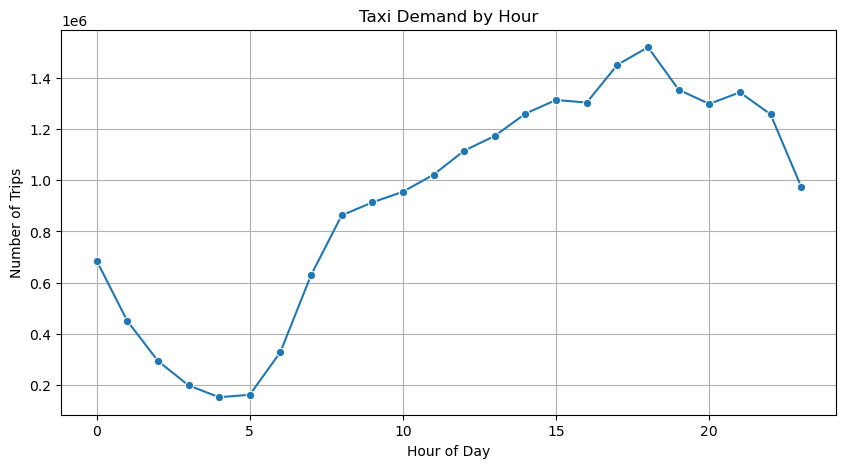

In [17]:
# ------------------------------
# 9. Demand Analysis
# ------------------------------

# Trips by hour
hourly_demand = df.groupby("pickup_hour").size().reset_index(name="trip_count")

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_demand, x="pickup_hour", y="trip_count", marker="o")
plt.title("Taxi Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

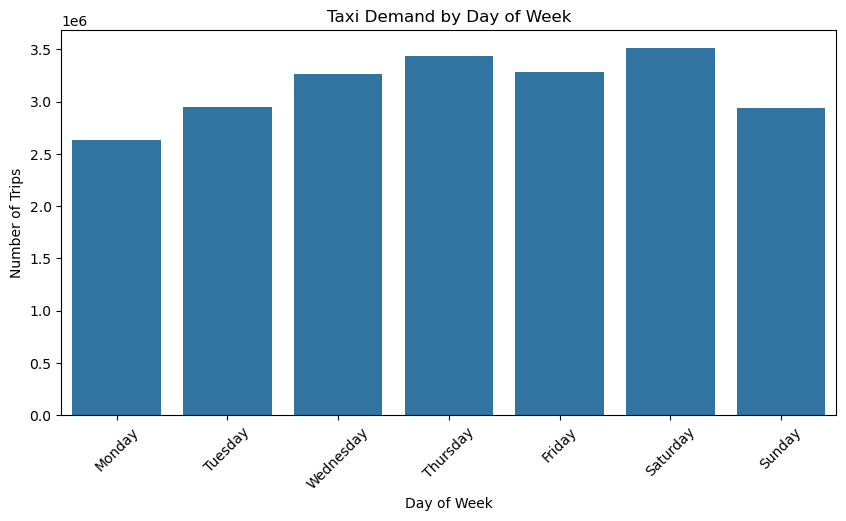

In [18]:
# Trips by day
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_demand = (
    df.groupby("day_name")
    .size()
    .reindex(day_order)
    .reset_index(name="trip_count")
)

plt.figure(figsize=(10,5))
sns.barplot(data=daily_demand, x="day_name", y="trip_count")
plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

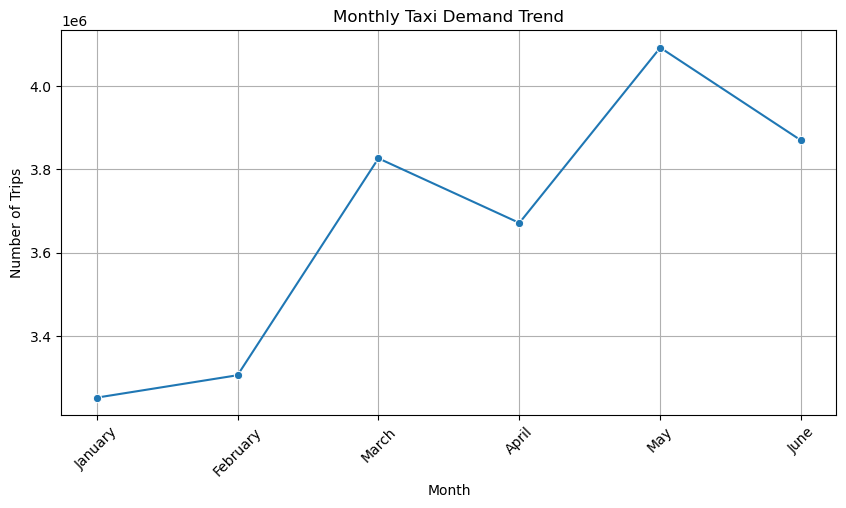

In [19]:
# Trips by month
monthly_demand = df.groupby("month_name").size().reset_index(name="trip_count")

month_order = ["January", "February", "March", "April", "May", "June"]
monthly_demand["month_name"] = pd.Categorical(
    monthly_demand["month_name"],
    categories=month_order,
    ordered=True
)

monthly_demand = monthly_demand.sort_values("month_name")

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_demand, x="month_name", y="trip_count", marker="o")
plt.title("Monthly Taxi Demand Trend")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Across all three analyses, taxi demand appears to be strongly influenced by both temporal and behavioural factors. Demand peaks during evening commuting hours, is highest on Saturdays, and generally increased during the first half of 2025. These patterns suggest that commuting activities, weekend leisure travel, and seasonal changes all play important roles in shaping taxi usage across New York City. Such insights can help taxi operators better allocate drivers and resources during periods of high demand.

#### Question 3. Where is demand concentrated?

,pickup_borough,trip_count,trip_share_percent
3,Manhattan,19155360,87.024103
4,Queens,1997876,9.076487
1,Brooklyn,659921,2.998066
0,Bronx,154676,0.702704
6,Unknown,41427,0.188206
5,Staten Island,1789,0.008128
2,EWR,508,0.002308


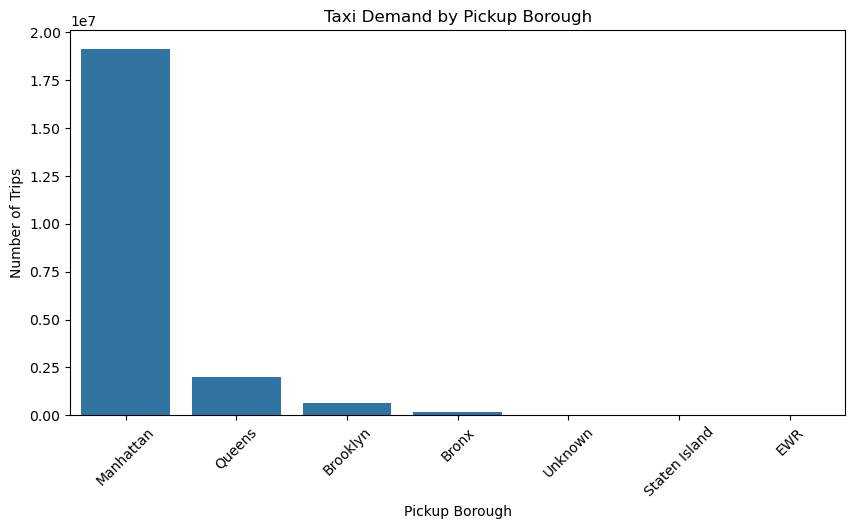

In [22]:
# ------------------------------
# 10. Geographic Analysis
# ------------------------------

borough_demand = (
    df.groupby("pickup_borough")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

borough_demand["trip_share_percent"] = (
    borough_demand["trip_count"] / borough_demand["trip_count"].sum() * 100
)

display(borough_demand)

plt.figure(figsize=(10,5))
sns.barplot(data=borough_demand, x="pickup_borough", y="trip_count")
plt.title("Taxi Demand by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

Taxi demand is heavily concentrated in Manhattan, which accounts for the vast majority of pickup trips during the study period. This is not surprising, as Manhattan is home to major business districts, tourist attractions, shopping areas, and transportation hubs. Queens records the second-highest demand, likely driven by airport traffic, while Brooklyn and the Bronx contribute a much smaller share of total trips. The results highlight the central role of Manhattan in New York City's taxi ecosystem.

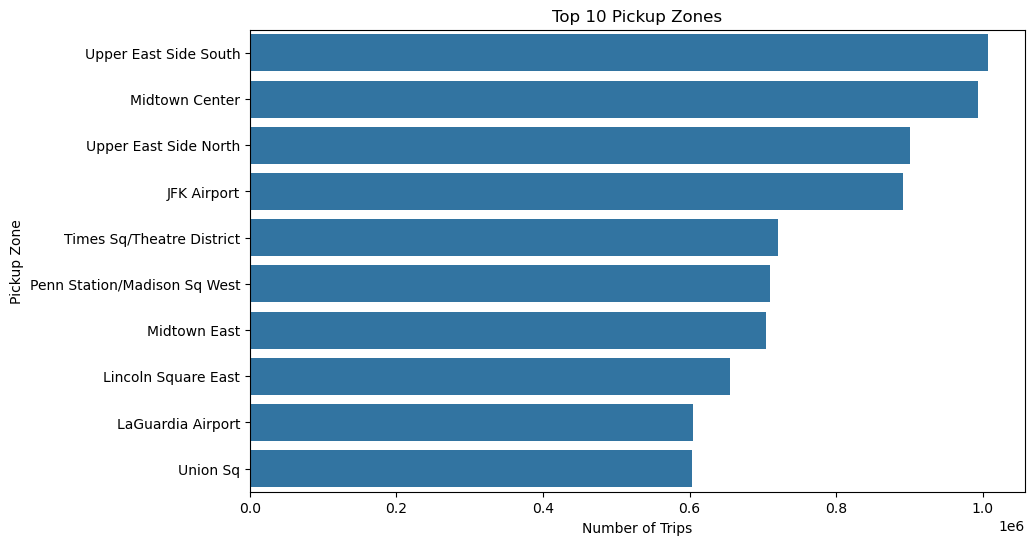

In [24]:
# ------------------------------
# Top 10 pickup zones
# ------------------------------

top_zones = (
    df.groupby("pickup_zone")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_zones, y="pickup_zone", x="trip_count")
plt.title("Top 10 Pickup Zones")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.show()

The busiest pickup locations are concentrated in well-known commercial, residential, and transportation areas. Upper East Side South, Midtown Center, and Upper East Side North generate the highest number of trips, reflecting their dense populations and strong economic activity. JFK Airport and LaGuardia Airport also appear among the top pickup zones, indicating the importance of airport-related travel. Overall, the most active pickup locations are areas where people frequently live, work, shop, or travel.

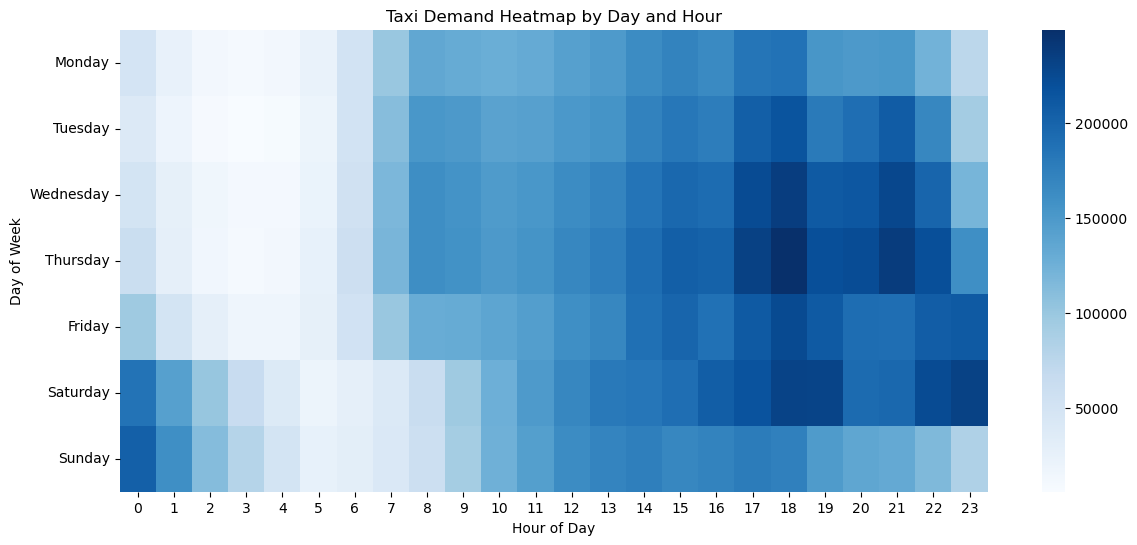

In [26]:
# ------------------------------
# 11. Demand Heatmap
# ------------------------------

heatmap_data = (
    df.groupby(["day_name", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

heatmap_pivot = heatmap_data.pivot(
    index="day_name",
    columns="pickup_hour",
    values="trip_count"
).reindex(day_order)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_pivot, cmap="Blues")
plt.title("Taxi Demand Heatmap by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

The heatmap reveals clear patterns in taxi demand throughout the week. Demand is generally low during the early morning hours but increases steadily throughout the day, reaching its highest levels in the late afternoon and evening. Weekdays show strong demand during traditional commuting periods, particularly between 5 PM and 7 PM. In contrast, weekends maintain higher demand later into the night, reflecting leisure, entertainment, and social activities. Saturday appears to be one of the busiest days overall, with consistently high demand across much of the day and evening.

#### Question 4. How much revenue is generated?

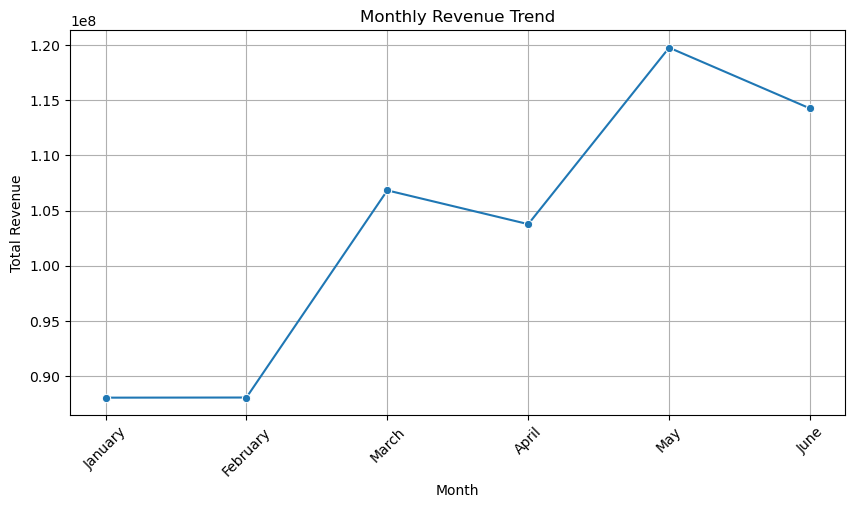

In [29]:
# ------------------------------
# 12. Revenue Analysis
# ------------------------------

monthly_revenue = (
    df.groupby("month_name")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

monthly_revenue["month_name"] = pd.Categorical(
    monthly_revenue["month_name"],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values("month_name")

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x="month_name", y="total_revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Revenue generally increased throughout the first half of 2025, indicating growing demand for taxi services. After remaining stable in January and February, revenue rose sharply in March, dipped slightly in April, and reached its highest level in May. Although June saw a small decline, overall revenue remained strong across the period.

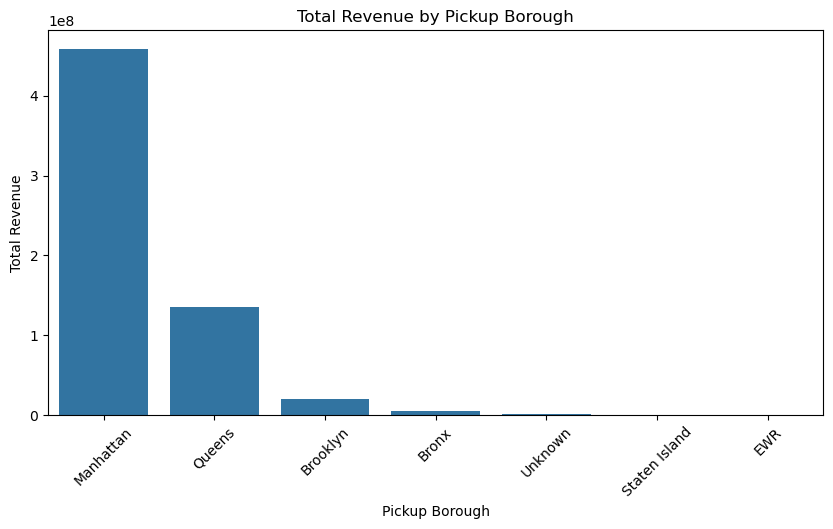

In [31]:
borough_revenue = (
    df.groupby("pickup_borough")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=borough_revenue, x="pickup_borough", y="total_revenue")
plt.title("Total Revenue by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

Manhattan generated by far the highest amount of taxi revenue, reflecting its position as New York City's main commercial and tourism centre. Queens ranked second, likely supported by airport-related travel. The remaining boroughs contributed considerably less revenue, highlighting how taxi activity and earnings are concentrated in a few key locations.

In [33]:
# Average fare by borough
avg_fare_borough = (
    df.groupby("pickup_borough")["fare_amount"]
    .mean()
    .reset_index(name="average_fare")
    .sort_values("average_fare", ascending=False)
)

display(avg_fare_borough)


,pickup_borough,average_fare
2,EWR,78.483524
4,Queens,50.170681
5,Staten Island,33.970481
0,Bronx,27.910924
1,Brooklyn,26.786883
6,Unknown,21.085199
3,Manhattan,15.849981


Average fares vary noticeably across boroughs. Airport-related locations such as EWR and Queens recorded the highest average fares, suggesting longer trips and higher travel costs. Manhattan, despite generating the most revenue overall, had the lowest average fare, indicating that its revenue is driven by a large volume of shorter trips.

#### Question 5. What travel behaviour can we observe?

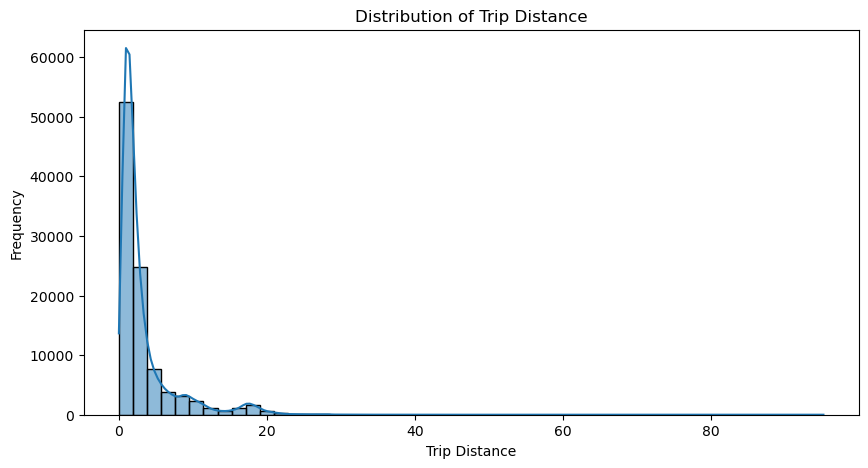

In [36]:
# ------------------------------
# 13. Travel Behaviour Analysis
# ------------------------------

sample_df = df.sample(min(100000, len(df)), random_state=42)

plt.figure(figsize=(10, 5))
sns.histplot(sample_df["trip_distance"], bins=50, kde=True)
plt.title("Distribution of Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()


The distribution shows that most taxi trips are relatively short, with the majority covering only a few miles. As trip distance increases, the number of trips decreases significantly. This suggests that taxis are primarily used for local urban travel, while longer journeys occur less frequently and represent a smaller share of demand.

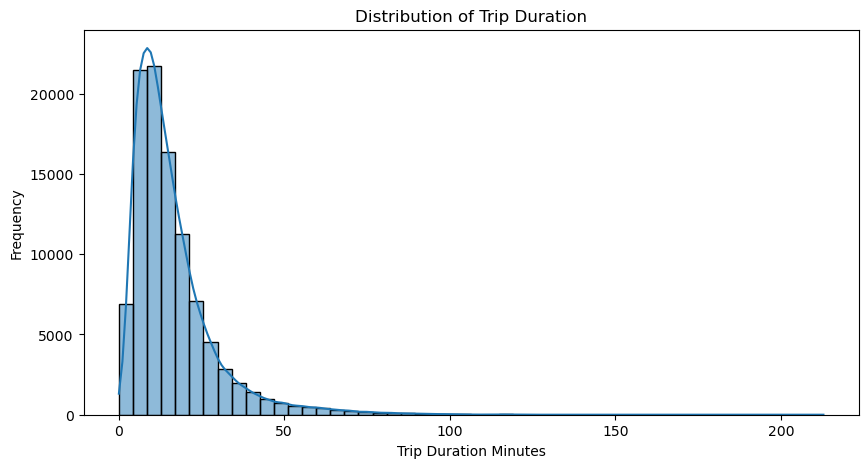

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(sample_df["trip_duration_minutes"], bins=50, kde=True)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration Minutes")
plt.ylabel("Frequency")
plt.show()


Most taxi journeys are completed within a short period of time, with trip durations heavily concentrated below 30 minutes. The distribution gradually tapers off as travel time increases, indicating that long-duration trips are relatively uncommon. This reflects the typical use of taxis for quick and convenient transportation within the city.

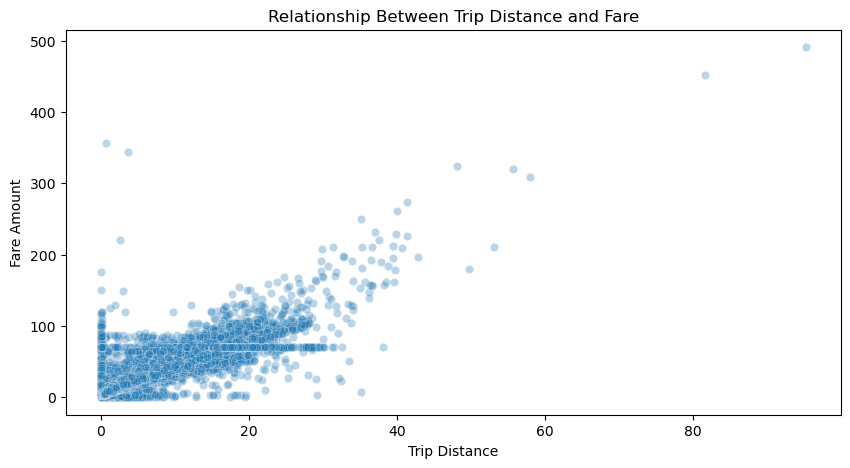

In [40]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample_df,
    x="trip_distance",
    y="fare_amount",
    alpha=0.3
)
plt.title("Relationship Between Trip Distance and Fare")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()

The scatter plot shows a clear positive relationship between trip distance and fare amount. In general, longer trips tend to result in higher fares, which aligns with standard taxi pricing structures. However, some variation exists due to factors such as traffic conditions, surcharges, tolls, and differences in trip duration.

#### Question 6. How do tipping patterns behave?

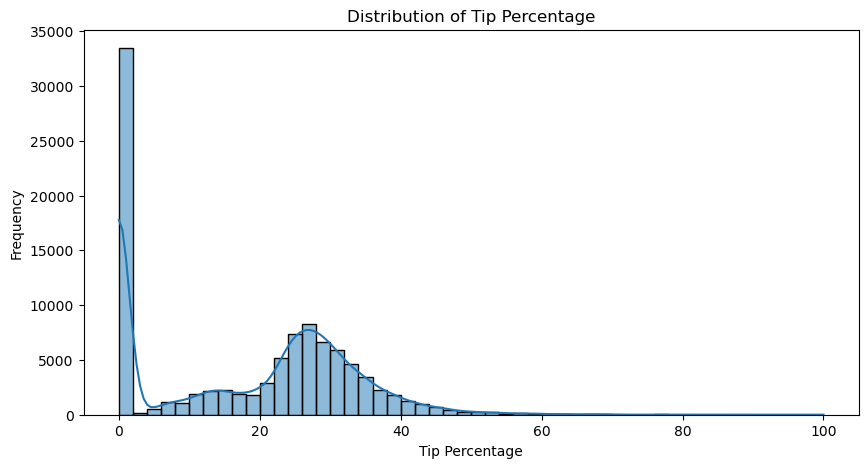

In [43]:
# ------------------------------
# 14. Tipping Analysis
# ------------------------------

# Remove extreme tip percentages for clearer visual
tip_df = sample_df[(sample_df["tip_percentage"] >= 0) & (sample_df["tip_percentage"] <= 100)]

plt.figure(figsize=(10, 5))
sns.histplot(tip_df["tip_percentage"], bins=50, kde=True)
plt.title("Distribution of Tip Percentage")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")
plt.show()

The distribution shows that most passengers leave tips within a fairly consistent range, with tip percentages commonly clustering around 20–30%. A noticeable number of trips receive little or no tip, while very high tip percentages are relatively rare. Overall, the results suggest that tipping is a common part of taxi travel behaviour.

,pickup_borough,average_tip_percentage
6,Unknown,19.403093
3,Manhattan,19.028608
4,Queens,14.023940
2,EWR,6.888889
1,Brooklyn,2.052032
0,Bronx,0.374726
5,Staten Island,0.000000


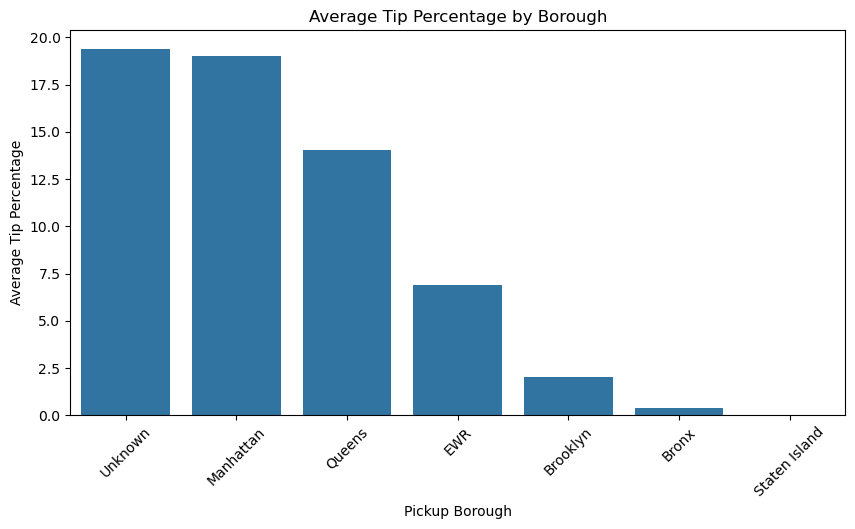

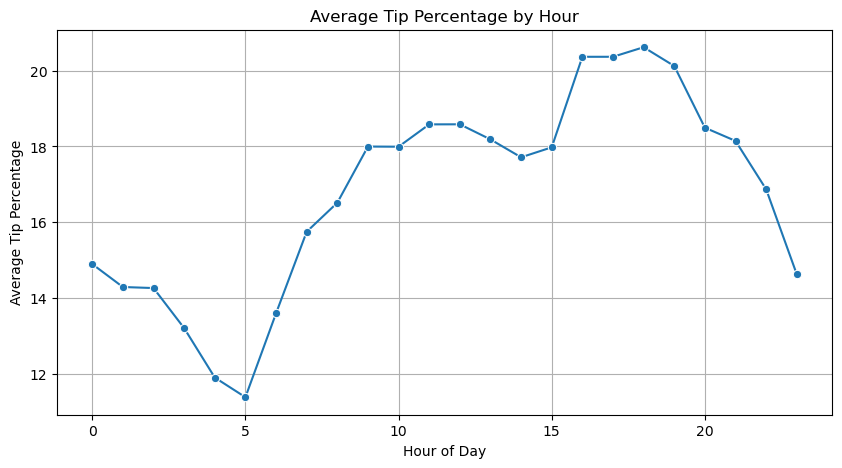

In [45]:
tip_by_borough = (
    tip_df.groupby("pickup_borough")["tip_percentage"]
    .mean()
    .reset_index(name="average_tip_percentage")
    .sort_values("average_tip_percentage", ascending=False)
)

display(tip_by_borough)

plt.figure(figsize=(10, 5))
sns.barplot(data=tip_by_borough, x="pickup_borough", y="average_tip_percentage")
plt.title("Average Tip Percentage by Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Average Tip Percentage")
plt.xticks(rotation=45)
plt.show()

tip_by_hour = (
    tip_df.groupby("pickup_hour")["tip_percentage"]
    .mean()
    .reset_index(name="average_tip_percentage")
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=tip_by_hour, x="pickup_hour", y="average_tip_percentage", marker="o")
plt.title("Average Tip Percentage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Tip Percentage")
plt.grid(True)
plt.show()

Tipping behaviour varies across boroughs, with Manhattan and Queens recording some of the highest average tip percentages. This may reflect differences in passenger demographics, trip purposes, or payment methods. In contrast, Brooklyn and the Bronx show lower average tipping levels, indicating that customer behaviour is not uniform across the city.

Tip percentages tend to increase throughout the day, reaching their highest levels during the late afternoon and evening hours. Lower tipping rates are observed during the early morning period when demand is relatively low. This pattern suggests that passenger generosity may be influenced by trip purpose, travel conditions, and time of day.

#### Question 7. Airport Travel Analysis

,is_airport_pickup,trip_count,total_revenue,average_fare,average_distance,average_duration,trip_type
0,0,20518963,5.047552e+08,16.713777,2.651025,14.680296,Non-Airport Pickup
1,1,1496603,1.159622e+08,56.231092,13.216787,37.822807,Airport Pickup


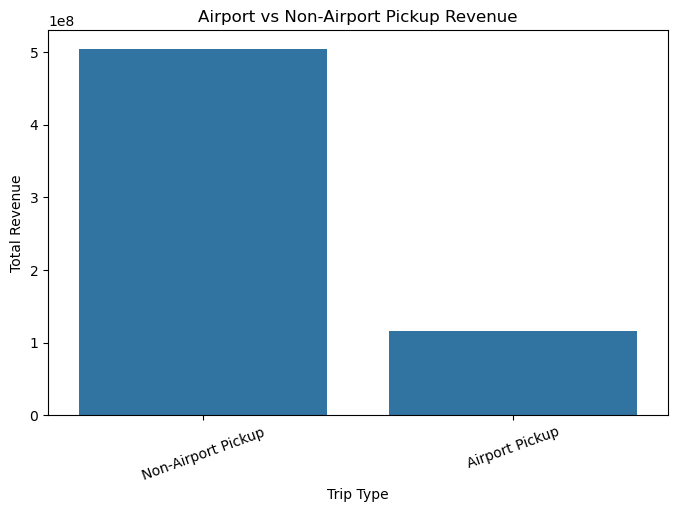

In [48]:
# ------------------------------------------------------------
# 15. Airport Analysis
# ------------------------------------------------------------

airport_zones = [
    "JFK Airport",
    "LaGuardia Airport",
    "Newark Airport"
]

df["is_airport_pickup"] = df["pickup_zone"].isin(airport_zones).astype(int)

airport_summary = df.groupby("is_airport_pickup").agg(
    trip_count=("total_amount", "count"),
    total_revenue=("total_amount", "sum"),
    average_fare=("fare_amount", "mean"),
    average_distance=("trip_distance", "mean"),
    average_duration=("trip_duration_minutes", "mean")
).reset_index()

airport_summary["trip_type"] = airport_summary["is_airport_pickup"].map({
    0: "Non-Airport Pickup",
    1: "Airport Pickup"
})

display(airport_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=airport_summary, x="trip_type", y="total_revenue")
plt.title("Airport vs Non-Airport Pickup Revenue")
plt.xlabel("Trip Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=20)
plt.show()

Airport and non-airport trips exhibit noticeably different travel patterns. While non-airport pickups generate the majority of total revenue due to their much higher trip volume, airport trips are considerably more valuable on a per-trip basis. Airport journeys have significantly higher average fares, longer travel distances, and longer trip durations. This suggests that although airport trips are less frequent, they contribute disproportionately to revenue and represent an important source of high-value taxi demand for operators.

### Phase 5 - Time-series Analysis

In [ ]:
# ------------------------------
# 16. Time-Series Analysis
# ------------------------------

df_2025 = df[
    (df["tpep_pickup_datetime"] >= "2025-01-01") &
    (df["tpep_pickup_datetime"] < "2025-07-01")
].copy()

hourly_ts = (
    df_2025.set_index("tpep_pickup_datetime")
    .resample("h")
    .size()
    .reset_index(name="trip_count")
)

hourly_ts["rolling_24h"] = (
    hourly_ts["trip_count"]
    .rolling(window=24)
    .mean()
)

hourly_ts["rolling_7d"] = (
    hourly_ts["trip_count"]
    .rolling(window=24*7)
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(
    hourly_ts["tpep_pickup_datetime"],
    hourly_ts["trip_count"],
    alpha=0.3,
    label="Hourly Demand"
)

plt.plot(
    hourly_ts["tpep_pickup_datetime"],
    hourly_ts["rolling_24h"],
    linewidth=2,
    label="24-Hour Rolling Average"
)

plt.plot(
    hourly_ts["tpep_pickup_datetime"],
    hourly_ts["rolling_7d"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("NYC Yellow Taxi Demand (Jan–Jun 2025)")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The time-series analysis reveals strong and recurring demand patterns throughout the first half of 2025. While hourly demand fluctuates considerably, both the 24-hour and 7-day rolling averages show a gradual upward trend over time. Demand appears to increase from January to May before stabilising, suggesting sustained growth in taxi usage. The regular peaks and troughs also indicate predictable daily and weekly travel behaviours, which can support more effective operational planning and resource allocation.

### Insights
- Taxi demand is strongly driven by time-based travel patterns.
- Manhattan is the centre of taxi activity and revenue generation.
- Airport trips and longer journeys create high-value revenue opportunities.

### What I would do if I were the manager of the Yellow Taxi Company

As a taxi company manager, I would focus on three priorities: matching driver supply with peak demand periods, concentrating fleet resources in Manhattan and other high-demand zones, and expanding airport-focused operations. Together, these initiatives would improve operational efficiency, increase revenue opportunities, and better align taxi services with observed customer travel behaviour.